# 1 Module, Globals und Daten

## 1.1 Module

In [2]:
##### IMPORTS #####

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

import sklearn.metrics as skm
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split, learning_curve

import os

import matplotlib.pyplot as pyplot



## 1.2 Globals

In [3]:
##### Globals #####
dataPath = 'datasets/harus/'


## 1.3 Daten

In [4]:
xdata = pd.read_csv(dataPath + "xdata.csv", sep=";")                     
ydata = pd.read_csv(dataPath + "ydata.csv", sep=";")

xtrain, xvaltest, ytrain, yvaltest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.66,
    stratify=ydata                                  # Preserve label imbalance across train- and test datasets
)

xval, xtest, yval, ytest = train_test_split( 
    xvaltest,
    yvaltest,
    random_state=0,
    train_size=0.5,
    stratify=yvaltest                                  # Preserve label imbalance across train- and test datasets
)

ev_val = [(xval,yval)]
ev_all = [(xtrain,ytrain),(xval,yval),(xtest,ytest)]

## 1.4 Funktionen

In [5]:
def plotReport(model):
    global xtest, ytest
    yhat = model.predict(xtest)
    print(f'\nAccuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
    print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
    # print(f'ROC AUC Score: {skm.roc_auc_score(ytest, model.predict_proba(xtest)[:, 1])}')
    print()
    print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking'],digits=6))

def plotConfusionMatrices(model):
    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='true')
    pyplot.title('')
    pyplot.show()

    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap="Blues" ,values_format='d')
    pyplot.show()

def plotLearningCurves(model):
    
    # https://xgboosting.com/xgboost-plot-learning-curve/

    global xtest, ytest
    
    # Calculate learning curves
    train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, X=xdata, y=ydata, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.75, 1.0, 10))

    # Calculate mean and standard deviation of scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curves
    pyplot.figure(figsize=(8, 6))
    pyplot.plot(train_sizes, train_mean, color='blue', marker='o', label='Training accuracy')
    pyplot.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    pyplot.plot(train_sizes, test_mean, color='green', marker='+', label='Validation accuracy')
    pyplot.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    pyplot.title('Learning Curves')
    pyplot.xlabel('Training set size')
    pyplot.ylabel('Accuracy')
    pyplot.grid()
    pyplot.legend(loc='lower right')
    pyplot.show()

def plotFeatureImportances(model):    
    iScores = model.feature_importances_
    fNames = model.feature_names_in_

    fig,ax = pyplot.subplots()
    ax.bar(fNames, iScores)
    ax.set_ylabel("Importance Scores")
    ax.set_xlabel("Features")

    pyplot.show()

def plotGeneralizationCurves(model, custom_names = None):
    results = model.evals_result()
    names = list(model.evals_result())
    lossValue = list(results[names[0]])[0]
    
    if custom_names == None:
        for i in names:
            pyplot.plot(results[i][lossValue], label=i)
    else:
        name_index = 0
        for i in names:
            pyplot.plot(results[i][lossValue], label=custom_names[name_index])
            name_index += 1

    pyplot.ylabel(lossValue)
    pyplot.xlabel('Iterations')
    pyplot.legend()
    pyplot.grid()
    pyplot.show()

def plotROC(model):
    global xtest, ytest
    
    y_pred_proba = model.predict_proba(xtest)[:, 1]
    
    fpr, tpr, threshold = skm.roc_curve(ytest, y_pred_proba)
    roc_auc = skm.auc(fpr, tpr)

    pyplot.figure(figsize=(8, 6))
    pyplot.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
    pyplot.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
    pyplot.xlim([0.0, 1.0])
    pyplot.ylim([0.0, 1.05])
    pyplot.xlabel('False Positive Rate')
    pyplot.ylabel('True Positive Rate')
    pyplot.title('Receiver Operating Characteristic (ROC) Curve')
    pyplot.legend(loc="lower right")
    pyplot.show()

def checkOverfitting(model):
    global xtrain, ytrain, xtest, ytest
    print("Flat Scores:")
    train_acc = skm.accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}\n')

    print("Balanced Scores:")
    train_acc = skm.balanced_accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.balanced_accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}')

def getBestDepth(listOfAccuracies, listOfSizes):  
        data = {'Accuracy': listOfAccuracies,
                'Size': listOfSizes}
        AccVsSize = pd.DataFrame(data)
        Suitable = AccVsSize[AccVsSize['Size']<1024]
        bestAccsWithinBoundaries = Suitable[Suitable['Accuracy']==max(Suitable['Accuracy'])]
        bestDepth = bestAccsWithinBoundaries[bestAccsWithinBoundaries['Size'] == min(bestAccsWithinBoundaries['Size'])]

        return bestDepth

def plotMicroAvgROC(model):

    # https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#roc-curve-using-micro-averaged-ovr

    global xtest, ytest

    yscore = model.predict_proba(xtest)

    label_binarizer = LabelBinarizer().fit(ytest)
    y_onehot_test = label_binarizer.transform(ytest)

    display = RocCurveDisplay.from_predictions(
    y_onehot_test.ravel(),
    yscore.ravel(),
    name="micro-average OvR",
    color="darkorange",
    plot_chance_level=True,
    despine=True,
    )
    _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic",
    )
    pyplot.grid()
    pyplot.show()
    
    micro_roc_auc_ovr = skm.roc_auc_score(
    ytest,
    yscore,
    multi_class="ovr",
    average="micro",
    )

    print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{micro_roc_auc_ovr:.2f}")


def plotMacroAvgROC(model):
    # https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#roc-curve-using-the-ovr-macro-average
    
    global xtest, ytest

    n_classes = len(np.unique(ytest))
    yscore = model.predict_proba(xtest)

    label_binarizer = LabelBinarizer().fit(ytest)
    y_onehot_test = label_binarizer.transform(ytest)

    # store the fpr, tpr, and roc_auc for all averaging strategies
    fpr, tpr, roc_auc = dict(), dict(), dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = skm.roc_curve(y_onehot_test[:, i], yscore[:, i])
        roc_auc[i] = skm.auc(fpr[i], tpr[i])

    fpr_grid = np.linspace(0.0, 1.0, 1000)

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation

    # Average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = skm.auc(fpr["macro"], tpr["macro"])

    print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")

    fig, ax = pyplot.subplots(figsize=(6, 6))

    pyplot.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
        color="navy",
        linestyle="-",
        linewidth=2,
    )
    pyplot.legend()
    pyplot.grid()
    pyplot.show()

def calculate_confusion_counts(ycompare, values):
    for val in values:
        tp = ycompare[(ycompare["true"] == val) & (ycompare["predicted"] == val)].shape[0]
        fp = ycompare[(ycompare["true"] == val) & (ycompare["predicted"] != val)].shape[0]
        tn = ycompare[(ycompare["true"] != val) & (ycompare["predicted"] != val)].shape[0]
        fn = ycompare[(ycompare["true"] != val) & (ycompare["predicted"] == val)].shape[0]

        print(f'{val}: TP {tp}, FP {fp}, TN {tn}, FN {fn}')

# 2 Modell

## 2.1 Vanilla-Modell und Best Iteration finden

In [6]:
# clf_vanilla = XGBClassifier(
#     objective = "multi:softmax",
#     tree_method = 'exact',
#     n_estimators = 100000,
#     early_stopping_rounds = 10,
#     )


# clf_vanilla.fit(
#     xtrain, ytrain,
#     eval_set = ev_val,
#     verbose = 0
# )

# print(f'Best Iteration based on Test-Data: {clf_vanilla.best_iteration}')

# plotConfusionMatrices(clf_vanilla)
# plotGeneralizationCurves(clf_vanilla,["Training","validation","Test"])
# plotReport(clf_vanilla)
# checkOverfitting(clf_vanilla)

# new_n_estimators = clf_vanilla.early_stopping_rounds + clf_vanilla.best_iteration
# bestIteration = clf_vanilla.best_iteration

# clf_vanilla.set_params(
#     n_estimators = new_n_estimators,
#     early_stopping_rounds = None
# )
# clf_vanilla.fit(
#     xtrain, ytrain,
#     eval_set = ev_all,
#     verbose = 0
# )

# plotConfusionMatrices(clf_vanilla)
# plotGeneralizationCurves(clf_vanilla,["Training","validation","Test"])
# # plotROC(clf_vanilla)
# plotReport(clf_vanilla)
# checkOverfitting(clf_vanilla)

## 2.2 Modell unter Berücksichtigung von Best Iteration

In [7]:
# clf_bestIteration = XGBClassifier(
#     objective = "multi:softmax",
#     tree_method = 'exact',
#     n_estimators = bestIteration,
#     )

# clf_bestIteration.fit(
#     xtrain, ytrain,
#     eval_set = ev_all,
#     verbose = 0
# )

# print(f'Amount of Estimators: \t\t{bestIteration}')
# plotConfusionMatrices(clf_bestIteration)
# plotGeneralizationCurves(clf_bestIteration,["Training","validation","Test"])
# # plotROC(clf_bestIteration)
# plotReport(clf_bestIteration)
# checkOverfitting(clf_bestIteration)

## 2.3 Modellverhalten bei variierender Baumtiefe untersuchen


### 2.3.1 Modelle erzeugen und Daten sammeln

In [ ]:
bestIterList = []
accList = []
ubjSizeList = []
jsonSizeList = []

maximum = 30

for i in range(1,maximum+1):
    clf_iter = XGBClassifier(objective = "multi:softmax",
                            tree_method = 'exact',
                            n_estimators = 100000,
                            early_stopping_rounds = 10,
                            max_depth = i
                            )

    clf_iter.fit(xtrain,ytrain,
                eval_set=ev_val,
                verbose = 0
                )

    bestIter_local = clf_iter.best_iteration
    acc_local = skm.accuracy_score(ytest,clf_iter.predict(xtest, iteration_range=(0,clf_iter.best_iteration)))
    
    clf_iter = XGBClassifier(objective = "multi:softmax",
                            tree_method = 'exact',
                            n_estimators = bestIter_local,
                            early_stopping_rounds = None,
                            max_depth = i
                            )

    clf_iter.fit(xtrain,ytrain,
                eval_set=ev_val,
                verbose = 0
                )

    clf_iter.save_model('clf_iter.ubj')
    clf_iter.save_model('clf_iter.json')
    
    ubjSizeList.append(os.path.getsize('clf_iter.ubj'))
    jsonSizeList.append(os.path.getsize('clf_iter.json'))
    bestIterList.append(bestIter_local)
    accList.append(acc_local)

    print("Im still alive!")

### 2.3.2 Gesammelte Daten visualisieren

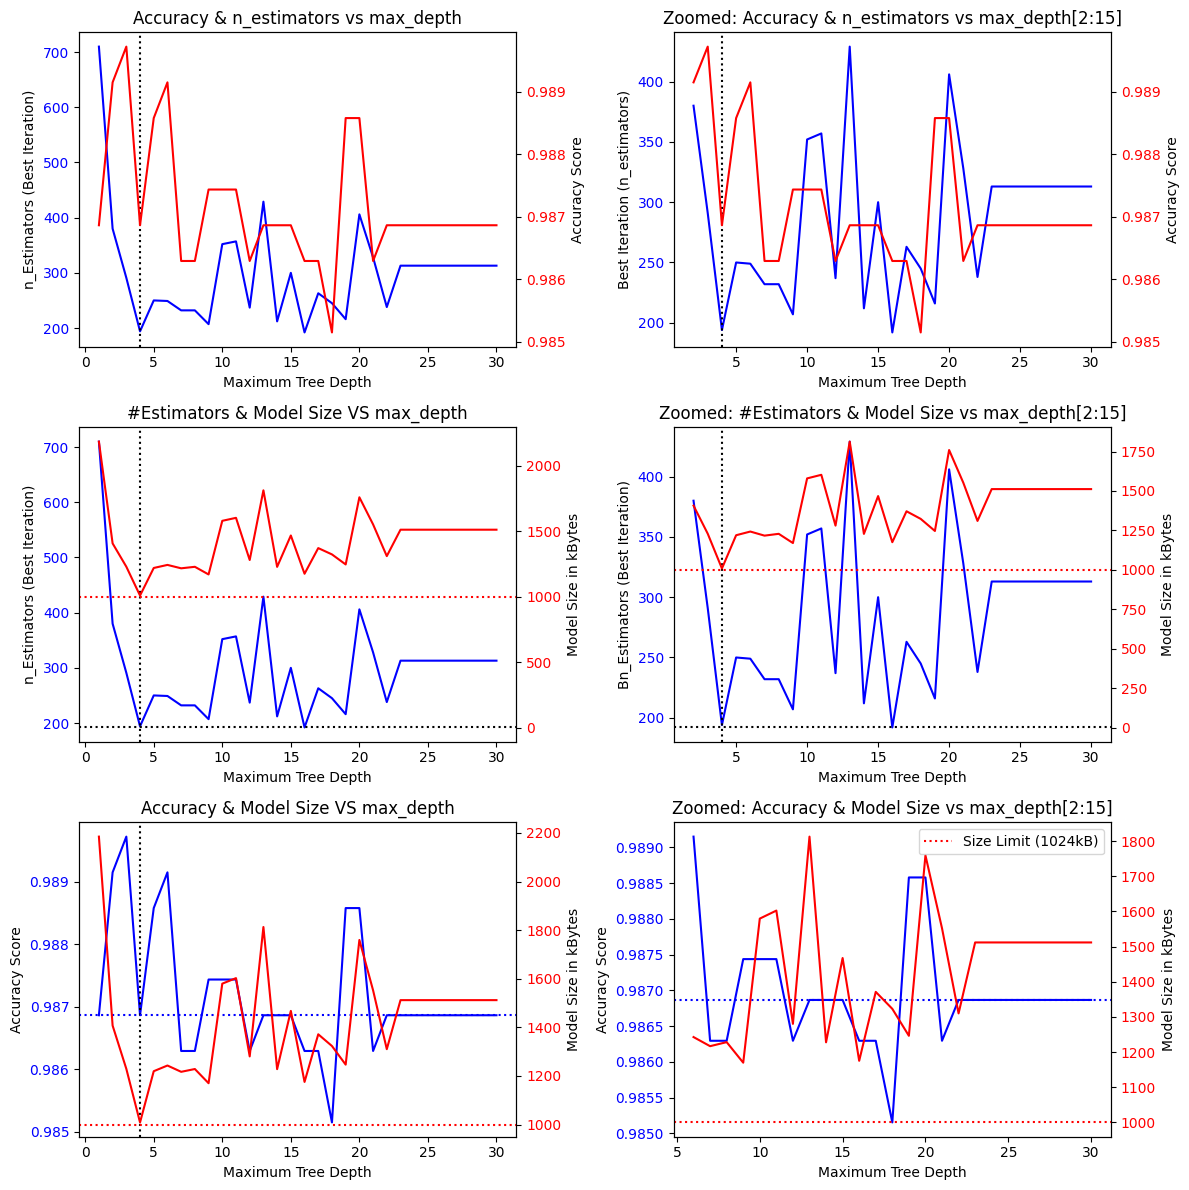

In [9]:
# Plot Accuracy vs Complexity

ubjSizeList_kB = [x/1024 for x in ubjSizeList]
jsonSizeList_kB = [x/1024 for x in jsonSizeList]

# bestDepth_df = getBestDepth(accList, ubjSizeList_kB)
bestDepth_df = getBestDepth(accList, jsonSizeList_kB)

final_depth = bestDepth_df.index[0]+1
# final_depth = 4
final_size = bestDepth_df['Size'].values[0]
# final_size = jsonSizeList_kB[final_depth-1]
final_acc = bestDepth_df['Accuracy'].values[0]
# final_acc = accList[final_depth-1]

fig, ax = pyplot.subplots(3,2)

fig.set_figwidth(12)
fig.set_figheight(12)

##### OBEN LINKS #####

ax[0][0].set_title("Accuracy & n_estimators vs max_depth")

ax[0][0].set_xlabel("Maximum Tree Depth")
ax[0][0].set_ylabel("n_Estimators (Best Iteration)")
ax[0][0].tick_params(axis='y', labelcolor="blue")
ax[0][0].plot(range(1,maximum+1),bestIterList,color="blue")

ax00_twin = ax[0][0].twinx()

ax00_twin.set_ylabel("Accuracy Score")
ax00_twin.tick_params(axis='y', labelcolor="red")
ax00_twin.plot(range(1,maximum+1),accList,color="red")

ax[0][0].axvline(x=final_depth, color="black", linestyle=":")

##### OBEN RECHTS #####

ax[0][1].set_title("Zoomed: Accuracy & n_estimators vs max_depth[2:15]")

ax[0][1].set_xlabel("Maximum Tree Depth")
ax[0][1].set_ylabel("Best Iteration (n_estimators)")
ax[0][1].tick_params(axis='y', labelcolor="blue")
ax[0][1].plot(range(2,maximum+1),bestIterList[1:],color="blue")

ax01_twin = ax[0][1].twinx()

ax01_twin.set_ylabel("Accuracy Score")
ax01_twin.tick_params(axis='y', labelcolor="red")
ax01_twin.plot(range(2,maximum+1),accList[1:],color="red")

ax[0][1].axvline(x=final_depth, color="black", linestyle=":")

##### MITTE LINKS #####

ax[1][0].set_title("#Estimators & Model Size VS max_depth")

ax[1][0].set_xlabel("Maximum Tree Depth")
ax[1][0].set_ylabel("n_Estimators (Best Iteration)")
ax[1][0].tick_params(axis='y', labelcolor="blue")
ax[1][0].plot(range(1,maximum+1),bestIterList,color="blue")

ax10_twin = ax[1][0].twinx()

ax10_twin.set_ylabel("Model Size in kBytes")
ax10_twin.tick_params(axis='y', labelcolor="red")
# ax10_twin.plot(range(1,maximum+1),ubjSizeList_kB,color="red")
ax10_twin.plot(range(1,maximum+1),jsonSizeList_kB,color="red")

ax10_twin.axhline(y=1000, color="red", linestyle=":")

ax[1][0].axvline(x=final_depth, color="black", linestyle=":")
ax10_twin.axhline(y=final_acc, color="black", linestyle=":")

##### MITTE RECHTS #####

ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[2:15]")
# ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[3:15]")

ax[1][1].set_xlabel("Maximum Tree Depth")
ax[1][1].set_ylabel("Bn_Estimators (Best Iteration)")
ax[1][1].tick_params(axis='y', labelcolor="blue")
ax[1][1].plot(range(2,maximum+1),bestIterList[1:],color="blue")
# ax[1][1].plot(range(3,maximum+1),bestIterList[2:],color="blue")

ax11_twin = ax[1][1].twinx()

ax11_twin.set_ylabel("Model Size in kBytes")
ax11_twin.tick_params(axis='y', labelcolor="red")
# ax11_twin.plot(range(2,maximum+1),ubjSizeList_kB[1:],color="red")
ax11_twin.plot(range(2,maximum+1),jsonSizeList_kB[1:],color="red")
# ax01_twin.plot(range(3,maximum+1),ubjSizeList_kB[2:],color="red")

ax11_twin.axhline(y=1000, color="red", linestyle=":")

ax[1][1].axvline(x=final_depth, color="black", linestyle=":")
ax11_twin.axhline(y=final_acc, color="black", linestyle=":")

##### UNTEN LINKS #####

ax[2][0].set_title("Accuracy & Model Size VS max_depth")

ax[2][0].set_xlabel("Maximum Tree Depth")
ax[2][0].set_ylabel("Accuracy Score")
ax[2][0].tick_params(axis='y', labelcolor="blue")
ax[2][0].plot(range(1,maximum+1),accList,color="blue")

ax20_twin = ax[2][0].twinx()

ax20_twin.set_ylabel("Model Size in kBytes")
ax20_twin.tick_params(axis='y', labelcolor="red")
# ax20_twin.plot(range(1,maximum+1),ubjSizeList_kB,color="red")
ax20_twin.plot(range(1,maximum+1),jsonSizeList_kB,color="red")

ax20_twin.axhline(y=1000, color="red", linestyle=":", label='Size Limit (1024kB)')

ax[2][0].axvline(x=final_depth, color="black", linestyle=":")
ax[2][0].axhline(y=final_acc, color="blue", linestyle=":")

##### UNTEN RECHTS #####

ax[2][1].set_title("Zoomed: Accuracy & Model Size vs max_depth[2:15]")
# ax[2][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[3:15]")

ax[2][1].set_xlabel("Maximum Tree Depth")
ax[2][1].set_ylabel("Accuracy Score")
ax[2][1].tick_params(axis='y', labelcolor="blue")
ax[2][1].plot(range(6,maximum+1),accList[5:],color="blue")
# ax[2][1].plot(range(3,maximum+1),accList[2:],color="blue")

ax21_twin = ax[2][1].twinx()

ax21_twin.set_ylabel("Model Size in kBytes")
ax21_twin.tick_params(axis='y', labelcolor="red")
# ax21_twin.plot(range(6,maximum+1),ubjSizeList_kB[5:],color="red")
ax21_twin.plot(range(6,maximum+1),jsonSizeList_kB[5:],color="red")
# ax21_twin.plot(range(3,maximum+1),ubjSizeList_kB[2:],color="red")

ax21_twin.axhline(y=1000, color="red", linestyle=":", label="Size Limit (1024kB)")

# ax[2][1].axvline(x=final_depth, color="black", linestyle=":")
ax[2][1].axhline(y=final_acc, color="blue", linestyle=":")

##### PLOT THAT THING #####
ax21_twin.legend()

fig.tight_layout()
pyplot.show()


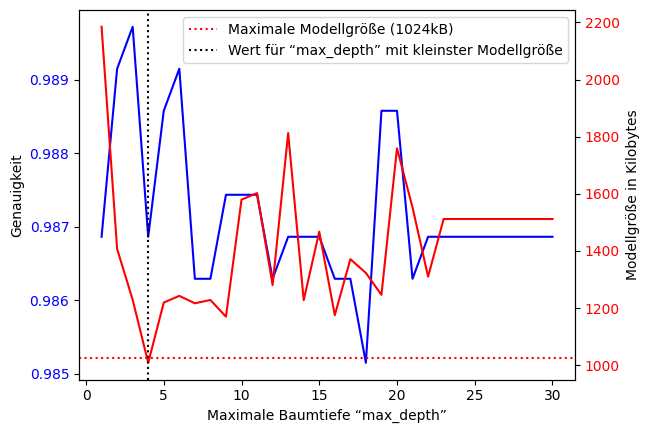

In [10]:
pyplot.xlabel("Maximale Baumtiefe “max_depth”")
pyplot.ylabel("Genauigkeit")
pyplot.tick_params(axis='y', labelcolor="blue")
pyplot.plot(range(1,31),accList,color="blue")
# pyplot.ylim(0.975,0.987)
# pyplot.axhline(y=final_acc, color="blue", linestyle=":")

ax20_twin = pyplot.twinx()

ax20_twin.set_ylabel("Modellgröße in Kilobytes")
ax20_twin.tick_params(axis='y', labelcolor="red")
ax20_twin.plot(range(1,maximum+1),jsonSizeList_kB,color="red")

ax20_twin.axhline(y=1024, color="red", linestyle=":", label='Maximale Modellgröße (1024kB)')
ax20_twin.axvline(x=final_depth, color="black", linestyle=":",label="Wert für “max_depth” mit kleinster Modellgröße")

pyplot.legend()

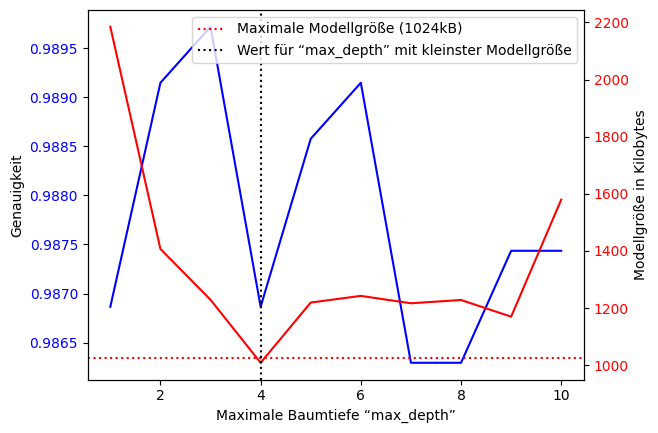

In [11]:
pyplot.xlabel("Maximale Baumtiefe “max_depth”")
pyplot.ylabel("Genauigkeit")
pyplot.tick_params(axis='y', labelcolor="blue")
pyplot.plot(range(1,11),accList[:10],color="blue")
# pyplot.ylim(0.975,0.987)
# pyplot.axhline(y=final_acc, color="blue", linestyle=":")

ax20_twin = pyplot.twinx()

ax20_twin.set_ylabel("Modellgröße in Kilobytes")
ax20_twin.tick_params(axis='y', labelcolor="red")
ax20_twin.plot(range(1,11),jsonSizeList_kB[:10],color="red")

ax20_twin.axhline(y=1024, color="red", linestyle=":", label='Maximale Modellgröße (1024kB)')
ax20_twin.axvline(x=final_depth, color="black", linestyle=":",label="Wert für “max_depth” mit kleinster Modellgröße")

pyplot.legend()

## 2.4 Basismodell mit Best Iteration und max_depth

In [17]:
clf_final = XGBClassifier(objective = "binary:logistic",
                            tree_method = 'exact',
                            n_estimators = bestIterList[final_depth-1],
                            max_depth = final_depth
                            )

print(bestIterList[final_depth-1])

clf_final.fit(xtrain,ytrain,
              eval_set=ev_all,
              verbose = 0
              )


194


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(4), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=194, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

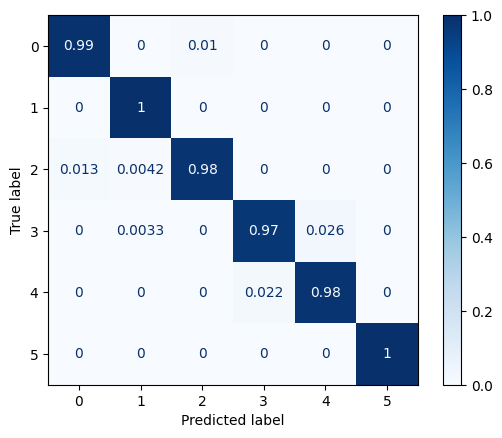

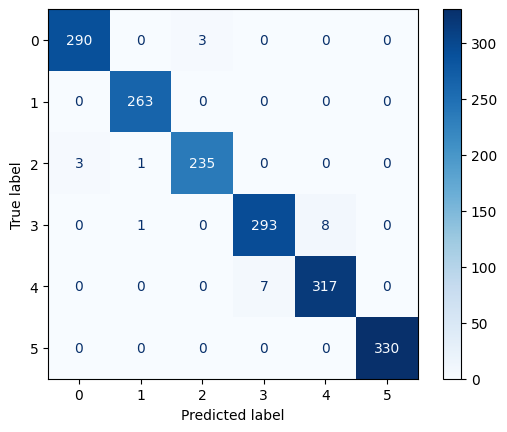

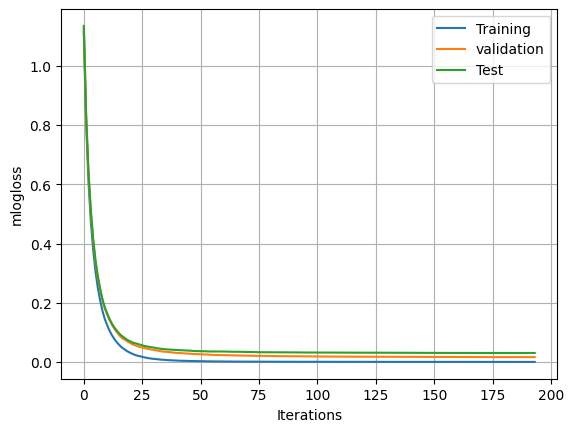

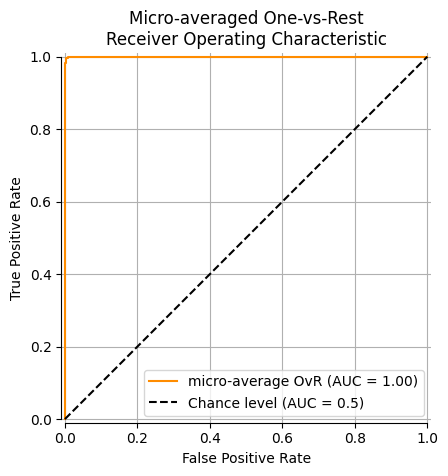

Micro-averaged One-vs-Rest ROC AUC score:
1.00
Macro-averaged One-vs-Rest ROC AUC score:
1.00


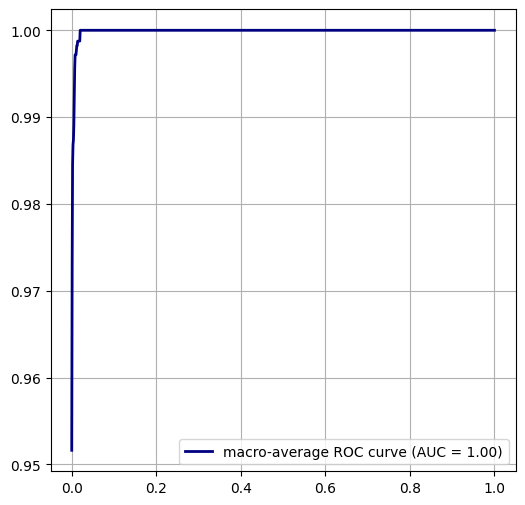


Accuracy Score: 		0.9868646487721302
Balanced Accuracy-Score: 	0.9869364046169357

              precision    recall  f1-score   support

 0: standing   0.989761  0.989761  0.989761       293
  1: walking   0.992453  1.000000  0.996212       263

   micro avg   0.991039  0.994604  0.992819       556
   macro avg   0.991107  0.994881  0.992987       556
weighted avg   0.991034  0.994604  0.992813       556

Flat Scores:
Accuracy Score mit Trainings-Datensatz: 1.0
Accuracy Score mit Test-Datensatz: 0.9868646487721302
Train-Test-Difference: 0.013135351227869796

Balanced Scores:
Accuracy Score mit Trainings-Datensatz: 1.0
Accuracy Score mit Test-Datensatz: 0.9869364046169357
Train-Test-Difference: 0.013063595383064341

Anzahl der Schätzer: 		194
Maximale Baumtiefe: 		4


Model Size in Bytes: 		1032757
Model Size in kiloBytes: 	1008.5517578125


In [13]:
plotConfusionMatrices(clf_final)
plotGeneralizationCurves(clf_final,["Training","validation","Test"])
plotMicroAvgROC(clf_final)
plotMacroAvgROC(clf_final)
plotReport(clf_final)
checkOverfitting(clf_final)

print(f'\nAnzahl der Schätzer: \t\t{bestIterList[final_depth-1]}')
print(f'Maximale Baumtiefe: \t\t{final_depth}\n')
# print(f'\nModel Size in Bytes: \t\t{ubjSizeList[final_depth-1]}')
# print(f'Model Size in kiloBytes: \t{ubjSizeList_kB[final_depth-1]}')
print(f'\nModel Size in Bytes: \t\t{jsonSizeList[final_depth-1]}')
print(f'Model Size in kiloBytes: \t{jsonSizeList_kB[final_depth-1]}')

## 2.5 Finales Basismodell sichern

In [18]:
clf_final.save_model("model-exports/base_harus_neu.ubj")
clf_final.save_model("model-exports/base_harus_neu.json")

## 2.6 Modell laden

In [15]:
clf_loaded = XGBClassifier(objective = "binary:logistic",
                           tree_method = 'exact',
                           n_estimators = 194,
                           max_depth = 4)
clf_loaded.load_model("model-exports/aktuelle-exports/base_harus_neu.json")

yhat = clf_loaded.predict(xtest)
yhatprob = clf_loaded.predict_proba(xtest)

print(type(yhat))

ycompare = pd.DataFrame()
ycompare['true'] = ytest
ycompare['predicted'] = yhat

calculate_confusion_counts(ycompare, [0,1,2,3,4,5])
# 0: TP 290, FP 3, TN 1455, FN 3
# 1: TP 263, FP 0, TN 1486, FN 2
# 2: TP 235, FP 4, TN 1509, FN 3
# 3: TP 293, FP 9, TN 1442, FN 7
# 4: TP 317, FP 7, TN 1419, FN 8
# 5: TP 330, FP 0, TN 1421, FN 0

tp0, tp1, tp2, tp3, tp4, tp5 = 290, 263, 235, 293, 317, 330
sumtp = tp0+tp1+tp2+tp3+tp4+tp5

fp0, fp1, fp2, fp3, fp4, fp5 = 3, 0, 4, 9, 7, 0
sumfp = fp0 + fp1 + fp2 + fp3 + fp4 + fp5

tn0, tn1, tn2, tn3, tn4, tn5 = 1455, 1486, 1509, 1442, 1419, 1421
sumtn = tn0 + tn1 + tn2 + tn3 + tn4 + tn5

fn0, fn1, fn2, fn3, fn4, fn5 = 3, 2, 3, 7, 8, 0
sumfn = fn0 + fn1 + fn2 + fn3 + fn4 + fn5

clf_loaded.get_booster().dump_model("model-exports/aktuelle-exports/base_harus_dump.json")

<class 'numpy.ndarray'>
0: TP 290, FP 3, TN 1455, FN 3
1: TP 263, FP 0, TN 1486, FN 2
2: TP 235, FP 4, TN 1509, FN 3
3: TP 293, FP 9, TN 1442, FN 7
4: TP 317, FP 7, TN 1419, FN 8
5: TP 330, FP 0, TN 1421, FN 0


In [19]:
clf_final.get_booster().dump_model("base_harus_dump.json")